In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOADING THE CSV DATASET

In [28]:
df = pd.read_csv('country_summary.csv')
df.head()

,country,total_titles,avg_imdb,top_platform,top_genre
0,Argentina,149,6.70,Netflix,Drama
1,Australia,294,6.74,Netflix,Drama
2,Brazil,301,6.85,Amazon Prime Video,Drama
3,Canada,440,6.76,Netflix,Drama
4,China,220,6.84,Netflix,Comedy


Anything missing 

In [29]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       24 non-null     object 
 1   total_titles  24 non-null     int64  
 2   avg_imdb      24 non-null     float64
 3   top_platform  24 non-null     object 
 4   top_genre     24 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.1+ KB


country         0
total_titles    0
avg_imdb        0
top_platform    0
top_genre       0
dtype: int64

Top 10 Countries have the most content

In [30]:
df.sort_values('total_titles',ascending=False).head(10)

,country,total_titles,avg_imdb,top_platform,top_genre
23,United States,5736,6.81,Netflix,Drama
9,India,1429,6.81,Netflix,Drama
22,United Kingdom,1369,6.80,Netflix,Drama
17,South Korea,1073,6.76,Netflix,Drama
13,Japan,907,6.85,Netflix,Drama
18,Spain,611,6.82,Netflix,Drama
7,France,555,6.83,Netflix,Drama
8,Germany,443,6.80,Netflix,Drama
3,Canada,440,6.76,Netflix,Drama
2,Brazil,301,6.85,Amazon Prime Video,Drama


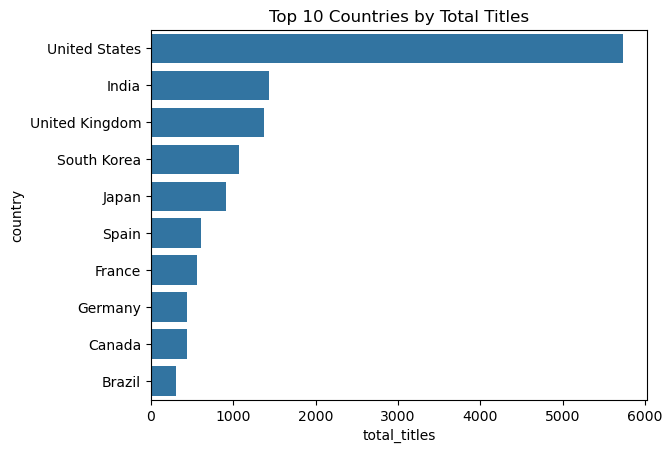

In [31]:
sns.barplot(data=df.sort_values('total_titles', ascending=False).head(10), x='total_titles', y='country')
plt.title("Top 10 Countries by Total Titles")
plt.show()

Which platform wins in most countries

In [32]:
df['top_platform'].value_counts()

top_platform
Netflix               20
Amazon Prime Video     3
Disney+                1
Name: count, dtype: int64

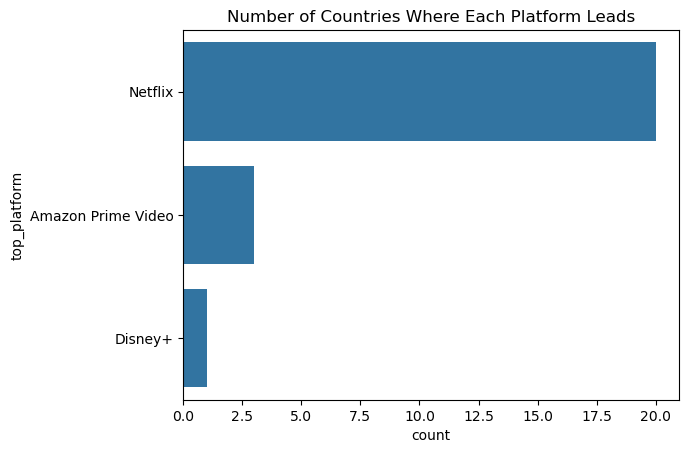

In [33]:
sns.countplot(data=df, y='top_platform', order=df['top_platform'].value_counts().index)
plt.title('Number of Countries Where Each Platform Leads')
plt.show()

In [34]:
df['title_rank'] = df['total_titles'].rank(ascending=False)

In [35]:
df.head()

,country,total_titles,avg_imdb,top_platform,top_genre,title_rank
0,Argentina,149,6.70,Netflix,Drama,16.0
1,Australia,294,6.74,Netflix,Drama,12.0
2,Brazil,301,6.85,Amazon Prime Video,Drama,10.0
3,Canada,440,6.76,Netflix,Drama,9.0
4,China,220,6.84,Netflix,Comedy,14.0


In [36]:
bins = [0, 100, 500, 6000]
labels = ['Small', 'Medium', 'Large']
df['library_size'] = pd.cut(df['total_titles'], bins=bins, labels=labels)

Comparing 
ratings across library-size categories

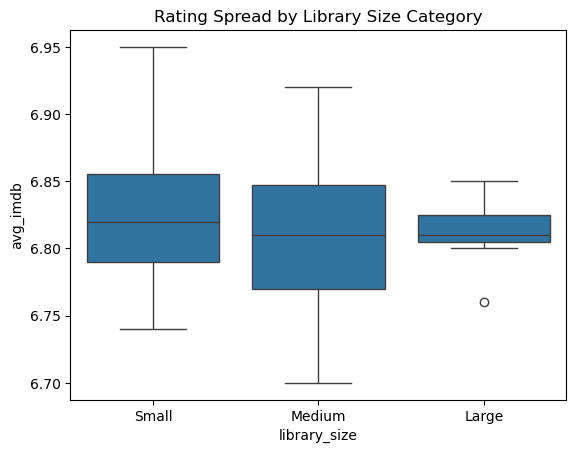

In [37]:
sns.boxplot(data=df,x='library_size',y='avg_imdb')
plt.title('Rating Spread by Library Size Category')
plt.show()

Comparing ratings across library-size categories

In [38]:
df.groupby('top_platform')['avg_imdb'].mean().sort_values(ascending=False)

top_platform
Amazon Prime Video    6.8300
Netflix               6.8145
Disney+               6.8000
Name: avg_imdb, dtype: float64

Simple correlation heatmap

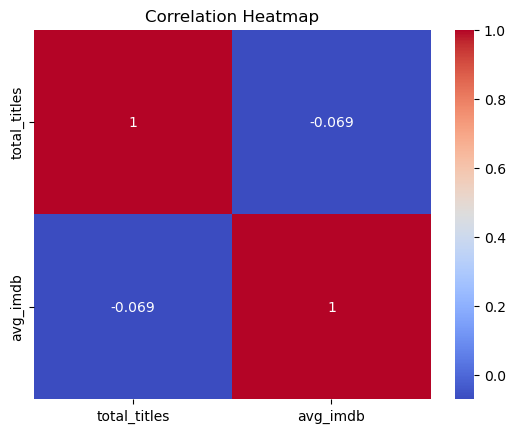

In [39]:
sns.heatmap(df[['total_titles','avg_imdb']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()